In [1]:
# === 第一段：匯入工具箱 ===
import os                                       # 【檔案管理】用來找電腦裡的資料夾和檔案路徑
import numpy as np                              # 【數學運算】用來處理大量的數據陣列
import matplotlib.pyplot as plt                 # 【畫圖主程式】用來繪製圖表
import matplotlib.cm as cm                      # 【調色盤】用來自動產生漸層顏色 (分辨不同樣品)
from matplotlib.ticker import MultipleLocator   # 【刻度設定】用來調整 X/Y 軸的刻度間距
from matplotlib.ticker import AutoMinorLocator  # 【刻度設定】用來自動產生次刻度
from matplotlib.ticker import FixedLocator      # 【刻度設定】用來設定固定的刻度位置
from scipy.signal import find_peaks             # 【訊號處理】用來找出數據中的峰值
from matplotlib.ticker import MaxNLocator      # 【刻度設定】用來設定最多顯示的刻度數量                  

In [2]:
# === 第二段：定義共用函數 (工具) ===

def normalize_intensity(intensity):
    """
    功能：將數據縮放到 0 到 1 之間
    原理：找出最大值，然後把所有數字都除以這個最大值
    """
    # 1. 安全檢查：如果最大值是 0 (代表完全沒訊號)，直接回傳，不然除法會當機
    if np.max(intensity) == 0: 
        return intensity
    
    # 2. 執行運算：每個數字 ÷ 最大值
    return intensity / np.max(intensity)

In [3]:
# === 第三段：精確讀取 (指定日期與標準品) ===

# ==========================================
# 1. 【控制台】請在這裡修改你要讀取的目標
# ==========================================

# 你的資料夾根目錄
base_path = 'XRDdata'      
material_name = 'ZnTe'     # 材料資料夾

# (A) 設定 Sample：你要讀哪個日期的資料夾？
target_date = '20260128'   # <--- 請改成你要的那個日期資料夾名稱

# (B) 設定 Standard：你要讀哪幾個標準品？(請填入檔名或關鍵字)
# 只要檔名裡面包含這些字，就會被讀取
target_std_names = ['ZnTe', 'Te'] # <--- 請修改成你想抓的標準品檔名片段

# ==========================================
# 2. 自動組合路徑
# ==========================================

# 組合出 Sample 的路徑: XRDdata/ZnTe/sample/20251120
sample_dir = os.path.join(base_path, material_name, 'sample', target_date)

# 組合出 Standard 的路徑: XRDdata/ZnTe/standard
standard_dir = os.path.join(base_path, material_name, 'standard')

# 準備記憶體清單
samples_data_list = []   
sample_filenames = []
ref_data_list = []       
ref_filenames = []

# ==========================================
# 3. 讀取 Sample (指定日期)
# ==========================================
if os.path.exists(sample_dir):
    print(f"📂 正在讀取樣品資料夾: {target_date}")
    for f in os.listdir(sample_dir):
        if f.endswith('.txt'):
            full_path = os.path.join(sample_dir, f)
            try:
                raw = np.loadtxt(full_path, skiprows=2, encoding='utf-8').T
                samples_data_list.append([raw[0], normalize_intensity(raw[1])])
                sample_filenames.append(f)
            except Exception as e:
                print(f"  ⚠️ 樣品讀取失敗 {f}: {e}")
else:
    print(f"❌ 找不到樣品路徑：{sample_dir}")

# ==========================================
# 4. 讀取 Standard (指定檔案)
# ==========================================
if os.path.exists(standard_dir):
    print(f"📂 正在精確篩選標準品...")
    
    all_stds = [f for f in os.listdir(standard_dir) if f.endswith('.xye')]
    
    for f in all_stds:
        f_name_only = os.path.splitext(f)[0]
        
        if f_name_only in target_std_names:
            full_path = os.path.join(standard_dir, f)
            try:
                raw = np.loadtxt(full_path, skiprows=2, encoding='utf-8').T
                ref_data_list.append([raw[0], normalize_intensity(raw[1])])
                ref_filenames.append(f_name_only)
                print(f"  -> ✅ 成功鎖定標準品: {f}")
            except Exception as e:
                print(f"  ⚠️ 讀取失敗 {f}: {e}")
else:
    print(f"❌ 找不到標準品路徑：{standard_dir}")

# ==========================================
# 5. 結果報告
# ==========================================
sample_filenames.sort()
print("-" * 30)
print(f"📊 讀取報告")
print(f"樣品 ({target_date}): 共 {len(sample_filenames)} 個")
print(f"標準品 (已篩選): 共 {len(ref_filenames)} 個 -> {ref_filenames}")
print("-" * 30)

📂 正在讀取樣品資料夾: 20260128
📂 正在精確篩選標準品...
  -> ✅ 成功鎖定標準品: Te.xye
  -> ✅ 成功鎖定標準品: ZnTe.xye
------------------------------
📊 讀取報告
樣品 (20260128): 共 3 個
標準品 (已篩選): 共 2 個 -> ['Te', 'ZnTe']
------------------------------


In [4]:
# === 第四段：繪製 Stack 圖 (分層堆疊) ===

# ==========================================
# 1. 【外觀控制台】
# ==========================================

# X 軸範圍
x_min = 20
x_max = 80

# 刻度設定
major_step = 5     # 每幾度一個大刻度？ (例如 10: 20, 30, 40...)
minor_subdivisions = 5 # 每個大刻度之間要分成幾等分？
tick_major_width = 2.5   # 大刻度粗細
tick_minor_width = 1.75  # 小刻度粗細
tick_major_length = 7    # 大刻度長度
tick_minor_length = 4    # 小刻度長度

# 文字設定
label_font_size = 14     # 軸標籤 (2-Theta) 字體大小
label_font_weight = 'bold' # 字體粗細 ('normal' 或 'bold')
legend_font_size = 14    # 圖例字體大小

# 畫案控制
fighigh = 3            # 每張圖的高度
axis_border_width = 2    # 框框與座標軸線粗細

#尋峰標籤模式選擇 ---
# 模式 1: 字是「橫的」
# 模式 2: 字是「直的」
label_mode = 1  

show_peak_dots = True   # 是否要在峰頂畫一個小圓點？ (True/False)
peak_dot_color = 'red'  # 圓點顏色

# [模式 1 專用參數]
model1_high_peak_threshold = 0.95 # 超過多少高度算「太高」？
mode1_x_shift = 2       # 太高時，字要往右移幾度？ (X Shift)

# [模式 2 專用參數]
model2_high_peak_threshold = 0.7 # 超過多少高度算「太高」？
mode2_x_shift = 1.5       # 太高時，字要往右移幾度？ (X Shift)

# 樣品抓峰設定 
enable_sample_label = True  # 是否要在樣品上標示角度？
noise_threshold = 0.1       # 門檻值：強度大於 0.2 才算訊號 (0~1之間)
peak_distance = 20          # 兩個峰之間的最小距離 (避免同一個寬峰被標兩次，單位是數據點)

# 標準品位置參數
std_mode1_y_down = 0.15   # 模式1: 標準品標籤要往「下」移多少
std_mode2_x_right = 1.2   # 模式2: 標準品標籤要往「右」移多少

# 標準品比對設定
std_match_tolerance = 1.0   # 容許誤差：自動抓到的峰跟字典差 1.0 度以內就算對應到

# 標準品晶面設定 (hkl) 
# 格式： '標準品檔名(不含.txt)': { 角度: '晶面名稱', 角度: '晶面名稱' }
# 如果一個位置有多個面，可以直接寫在一起，例如 '(111)/(200)'
hkl_labels = {
    'ZnTe': { 
        25.3: '(111)', 
        41.8: '(220)', 
        49.6: '(311)' 
    },
    'Te': {
        23.0: '(100)',
        27.6: '(101)'
    }
}


In [5]:
# ==========================================
# 2. 【工具區】
# ==========================================

# 定義一個小工具：把 ".txt" 拿掉
def clean_name(name):
    return name.replace('.txt', '')


# 定義一個內部小函式：負責畫標籤
def add_label(ax, x, y, text, color):
    # 決定是否畫點
    if show_peak_dots:
        ax.plot(x, y, 'o', color=peak_dot_color, markersize=3, zorder=10)


    # --- 模式 1: 橫字，不壓線 ---
    if label_mode == 1:
        if y > model1_high_peak_threshold:
            # 撞到了：X 往右移，Y 稍微降一點點讓它在線旁邊
            model1_final_x = x + mode1_x_shift
            model1_final_y = y - 0.1 # 稍微降一點，對齊峰的肩膀
            
            # 畫一條細線指回去 (選用，讓讀者知道這是指誰)
            # ax.plot([x, final_x], [y, final_y], '-', color='gray', linewidth=0.5) 
        else:
            # 沒撞到：正常標示在正上方
            model1_final_x = x
            model1_final_y = y +0.025

        ax.text(model1_final_x, model1_final_y , text, 
                ha='center', va='bottom', fontsize=9, color=color, rotation=0, fontweight='bold')

    # --- 模式 2: 直字，太高則 X Shift ---
    elif label_mode == 2:
        # 判斷是否撞到天花板
        if y > model2_high_peak_threshold:
            # 撞到了：X 往右移，Y 稍微降一點點讓它在線旁邊
            model2_final_x = x + mode2_x_shift
            model2_final_y = y - 0.15 # 稍微降一點，對齊峰的肩膀
            
            # 畫一條細線指回去 (選用，讓讀者知道這是指誰)
            # ax.plot([x, final_x], [y, final_y], '-', color='gray', linewidth=0.5) 
        else:
            # 沒撞到：正常標示在正上方
            model2_final_x = x
            model2_final_y = y + 0.05

        ax.text(model2_final_x, model2_final_y, text, 
                ha='center', va='bottom', fontsize=9, color=color, rotation=90, fontweight='bold')


# 處理軸與刻度的美化
def apply_axis_style(ax, i, num_plots):
    # 設定框框粗細
    for spine in ax.spines.values():
        spine.set_linewidth(axis_border_width)
        
    # ---  X 軸刻度控制 ---
    
    # 判斷：這是最後一張圖嗎？ (i 等於 總數-1)
    if i == num_plots - 1:
        # === 只有最下面的圖要做這些設定 ===
       
        # 1. 計算大刻度位置 (數學計算)
        # 產生從 min 到 max 的數列，間隔為 major_step
        custom_ticks = np.arange(x_min, x_max + 0.1, major_step)
        # 套用大刻度
        ax.set_xticks(custom_ticks)
        # 開啟小刻度
        ax.xaxis.set_minor_locator(AutoMinorLocator(minor_subdivisions))
        
        # 設定大刻度 (朝內)
        ax.tick_params(which='major', direction='in', length=tick_major_length, width=tick_major_width, top=False, right=True, bottom=True)
        # 設定小刻度 (朝內)
        ax.tick_params(which='minor', direction='in', length=tick_minor_length, width=tick_minor_width, top=False, right=True, bottom=True)
       
        #把「第一個」跟「最後一個」的刻度線(Line)隱藏
        # 取得所有的 ticks 物件
        ticks = ax.xaxis.get_major_ticks()
        
        # 隱藏第一個 (Index 0) 的線，但保留字
        ticks[0].tick1line.set_visible(False) 
        
        # 隱藏最後一個 (Index -1) 的線，但保留字
        ticks[-1].tick1line.set_visible(False)

    else:
        # === 上面的圖：把 X 軸刻度線隱藏起來 ===
        # bottom=False: 不要下面的刻度線
        # labelbottom=False: 不要下面的數字 (因為 sharex=True 預設就會隱藏數字，但保險起見再寫一次)
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    
    # 設定 Y 軸文字 (只寫 Intensity 或 Normalized)
    # ax.set_ylabel('Intensity', fontsize=10)
    
    # 隱藏 Y 軸刻度數字 (讓畫面比較乾淨)，如果想看數字把這行註解掉
    ax.set_yticks([]) 
    # 網格 (選用，目前設為 False 比較乾淨)
    ax.grid(False)
        



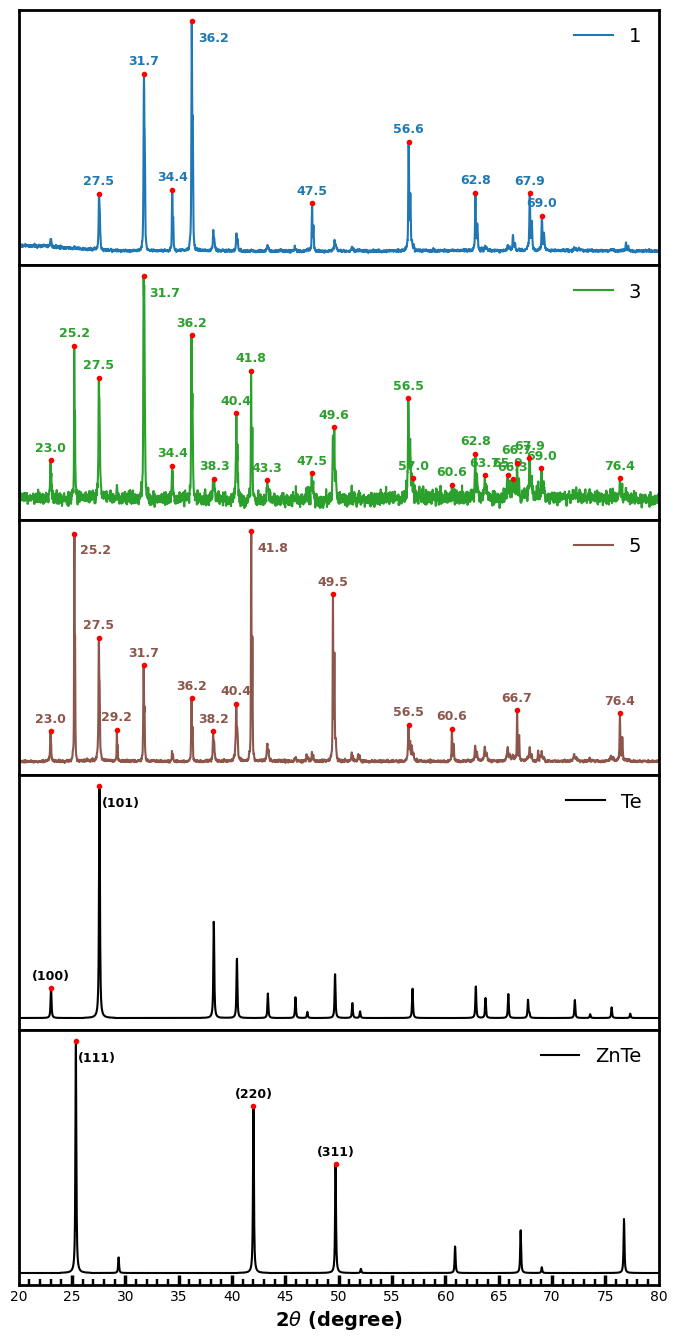

In [6]:
# ==========================================
# 3. 【執行區】主程式
# ==========================================
# 準備資料
# 清理樣品名稱 (原本有 .txt，現在切掉)
clean_sample_labels = [clean_name(name) for name in sample_filenames]

# 整合數據 (樣品在上，標準品在下)
all_data = samples_data_list + ref_data_list
# 整合標籤 (使用清理過的名字)
all_labels = clean_sample_labels + ref_filenames

num_plots = len(all_data) # 總共要畫幾張圖

if os.path.exists('ZnTe.cif'):
    hkl_labels['ZnTe'] = get_hkl_from_cif('ZnTe.cif')

if num_plots == 0:
    print("❌ 沒有資料可以畫圖！請檢查上一段讀取是否成功。")
else:
    # ==========================================
    # 3. 設定畫布 (動態調整高度)
    # ==========================================
    # sharex=True: 大家共用一個 X 軸
    # figsize: 高度設定為 (數量 * fighigh)，這樣圖越多越長，不會被擠扁
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(8, fighigh * num_plots))
    
    # 調整圖與圖之間的間距 (hspace=0 代表完全緊貼)
    fig.subplots_adjust(hspace=0, wspace=0.0, left=0.15, right=0.95, top=0.95, bottom=0.1)

    # ==========================================
    # 4. 迴圈繪圖
    # ==========================================
    # 如果只有 1 張圖，axs 不是列表，會報錯，所以強制轉成列表
    if num_plots == 1: axs = [axs]

    # 設定顏色循環 (這裡用 matplotlib 內建的 tab10 色票，超過 10 個會循環)
    colors = plt.cm.tab10(np.linspace(0, 1, num_plots))

    for i in range(num_plots):
        ax = axs[i]

        # 取出數據 (已經在讀取階段做過歸一化了，直接用)
        x_data = all_data[i][0]
        y_data = all_data[i][1] 
        label_name = all_labels[i]

        # 判斷：如果是標準品，用黑色；如果是樣品，用彩色
        # (這裡用簡單邏輯：如果標籤在標準品清單裡，就給黑色)
        is_standard = label_name in ref_filenames
        if label_name in ref_filenames:
            plot_color = 'black'
            line_style = '-' # 標準品用實線 (或改成 '--' 虛線)
        else:
            plot_color = colors[i % len(colors)]
            line_style = '-' # 樣品用實線

        # 畫圖
        ax.plot(x_data, y_data, linestyle=line_style, color=plot_color, label=label_name, linewidth=1.5)
        
        # ---------------------------------------------------
        #  樣品自動抓峰 (Peak Finding)
        # ---------------------------------------------------

        # 處理【樣品】的自動抓峰 
        if not is_standard and enable_sample_label:
            # 使用 scipy.signal.find_peaks
            # height: 過濾雜訊
            # distance: 兩個標籤至少要隔幾個點 (避免太密集)
            peaks, _ = find_peaks(y_data, height=noise_threshold, distance=peak_distance)
            
            # 畫出標籤
            for p in peaks:
                peak_x = x_data[p]
                peak_y = y_data[p]
                # 只標示在範圍內的
                if x_min <= peak_x <= x_max:
                    add_label(ax, peak_x, peak_y, f'{peak_x:.1f}', plot_color)
                
        # ---------------------------------------------------
        # 標準品晶面標記 (hkl Labeling)
        # ---------------------------------------------------
        if is_standard:
            # 檢查這個標準品有沒有在我們的字典裡
            # 嘗試模糊比對：只要字典的 key 包含在檔名裡就算 (例如 'ZnTe' in 'ZnTe_Ref')
            std_peaks, _ = find_peaks(y_data, height=noise_threshold, distance=peak_distance)
            target_key = None
            for key in hkl_labels.keys():
                if key in label_name:
                    target_key = key
                    break
            
            if target_key:
                # 取得該材料的晶面資料
                planes = hkl_labels[target_key]
                
                for p in std_peaks:
                    px, py = x_data[p], y_data[p]
                    
                    if x_min <= px <= x_max:
                        # 2. 比對此峰是否接近字典中的角度 (使用 std_match_tolerance)
                        matched_text = next((v for k, v in planes.items() if abs(px - k) < std_match_tolerance), None)
                        
                        # 3. 如果對應成功，呼叫智慧標籤並設定 is_std=True
                        if matched_text:
                            add_label(ax, px, py, matched_text, 'black')
                        
                        # 畫一條虛線指下來 (選用)
                        # ax.vlines(angle, 0, y_pos, color='gray', linestyle=':', linewidth=0.8)



       
   # 4. 套用外觀設定 
        apply_axis_style(ax, i, num_plots)
        ax.legend(loc='upper right', frameon=False, fontsize=legend_font_size)     
        
    # 5. 整體設定 (只對最下面的軸設定 X 軸)
    # 設定 X 軸範圍 
    plt.xlim(x_min, x_max )
    # 設定最下方的 X 軸標籤
    plt.xlabel(r'2$\theta$ (degree)', fontsize=label_font_size, fontweight=label_font_weight)
    plt.show()